## Training example

Train a model based on the first 4 months of data.

You'll need to run the the preprocessing notebook before this one in order for things to run as expected.

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print("Using CUDA (NVIDIA GPU)")
elif DEVICE.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("Using MPS (Apple Silicon GPU)")
else:
    DEVICE = torch.device("cpu")
    print("Using CPU")

# 2. Reproducibility
# We set the seed so our "random" splits are always the same
torch.manual_seed(42)
np.random.seed(42)

# 3. Load the Fuel
DATA_PATH = '../data/processed/jantoapr_2025_processed.csv'
df = pd.read_csv(DATA_PATH)

print(f"Data Loaded. Shape: {df.shape}")

Using CUDA (NVIDIA GPU)
Data Loaded. Shape: (2188776, 14)


## The Dataset Class

In [2]:
class FlightDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe
        
        # --- INPUTS ---
        # 1. Categorical (Integers for Embeddings)
        self.cat_cols = ['airline_idx', 'origin_idx', 'dest_idx', 'month_idx', 'dayofweek_idx']
        # Convert to numpy int64, then to Tensor later
        self.X_cat = self.df[self.cat_cols].values.astype(np.int64)
        
        # 2. Numerical (Floats for Linear Layers)
        self.num_cols = ['dep_sin', 'dep_cos', 'arr_sin', 'arr_cos', 
                         'day_sin', 'day_cos', 'distance_scaled']
        self.X_num = self.df[self.num_cols].values.astype(np.float32)
        
        # --- TARGETS ---
        # Target 1: Delay Minutes (Regression)
        self.y_reg = self.df['ARR_DELAY'].values.astype(np.float32)
        
        # Target 2: Late Flag (Classification)
        self.y_cls = self.df['ARR_DEL15'].values.astype(np.float32)
        
    def __len__(self):
        # Tells the DataLoader how many items we have
        return len(self.df)
    
    def __getitem__(self, idx):
        # Retrieves the item at row 'idx'
        return {
            'x_cat': torch.tensor(self.X_cat[idx]),
            'x_num': torch.tensor(self.X_num[idx]),
            'y_reg': torch.tensor(self.y_reg[idx]),
            'y_cls': torch.tensor(self.y_cls[idx])
        }

print("Dataset Class Defined.")

Dataset Class Defined.


## Prepare Loaders

In [3]:
# 1. Split (80% Train, 20% Validation)
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

# 2. Instantiate Datasets
train_dataset = FlightDataset(train_df)
val_dataset = FlightDataset(val_df)

# 3. Instantiate Loaders
# batch_size=64 means we feed 64 flights at a time to the brain
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training on {len(train_df)} flights.")
print(f"Validating on {len(val_df)} flights.")

# 4. SANITY CHECK
# Let's verify the shape of one batch to ensure no errors
sample_batch = next(iter(train_loader))
print("\n--- Batch Shape Verification ---")
print(f"Cat Inputs: {sample_batch['x_cat'].shape} (Should be [64, 5])")
print(f"Num Inputs: {sample_batch['x_num'].shape} (Should be [64, 7])")
print(f"Targets:    {sample_batch['y_reg'].shape} (Should be [64])")

Training on 1751020 flights.
Validating on 437756 flights.

--- Batch Shape Verification ---
Cat Inputs: torch.Size([64, 5]) (Should be [64, 5])
Num Inputs: torch.Size([64, 7]) (Should be [64, 7])
Targets:    torch.Size([64]) (Should be [64])


## Define Embedding Configs

In [4]:
# 1. Get the counts (vocab sizes) from the dataframe
# We add +1 to handle potential unknown categories (just in case), though our cleaning should prevent this.
num_airlines = df['airline_idx'].max() + 1
num_airports = max(df['origin_idx'].max(), df['dest_idx'].max()) + 1
num_months = df['month_idx'].max() + 1
num_days = df['dayofweek_idx'].max() + 1

print(f"Vocab Sizes -> Airlines: {num_airlines}, Airports: {num_airports}, Months: {num_months}, Days: {num_days}")

# 2. Define Embedding Dimensions (How rich is the 'personality' vector?)
# Structure: (Input Size, Output Vector Size)
embedding_config = {
    'airline': (num_airlines, 8),      # 14 airlines -> vector of size 8
    'airport': (num_airports, 20),     # 329 airports -> vector of size 20
    'month':   (num_months, 4),        # 12 months -> vector of size 4
    'day':     (num_days, 4)           # 7 days -> vector of size 4
}

# Calculate total size after embeddings are flattened
# 8 + 20 + 20 + 4 + 4 = 56
emb_output_dim = sum([v[1] for v in embedding_config.values()]) 
# Note: We add 'airport' twice because we have Origin AND Dest
emb_output_dim += embedding_config['airport'][1] 

print(f"Total Embedding Vector Size: {emb_output_dim}")

Vocab Sizes -> Airlines: 14, Airports: 333, Months: 4, Days: 7
Total Embedding Vector Size: 56


## Neural Network Architecture

In [5]:
class FlightPredictor(nn.Module):
    def __init__(self, emb_config, num_numerical_cols):
        super(FlightPredictor, self).__init__()
        
        # --- 1. EMBEDDING LAYERS ---
        # Lookups for categorical features
        self.emb_airline = nn.Embedding(emb_config['airline'][0], emb_config['airline'][1])
        self.emb_origin = nn.Embedding(emb_config['airport'][0], emb_config['airport'][1])
        self.emb_dest = nn.Embedding(emb_config['airport'][0], emb_config['airport'][1])
        self.emb_month = nn.Embedding(emb_config['month'][0], emb_config['month'][1])
        self.emb_day = nn.Embedding(emb_config['day'][0], emb_config['day'][1])
        
        # Calculate input size for the dense layers
        # Sum of all embedding outputs + number of numerical columns
        # (8 + 20 + 20 + 4 + 4) + 7 (numerical) = 63 inputs
        total_input_size = 56 + num_numerical_cols
        
        # --- 2. SHARED LAYERS (The Body) ---
        # A simple Feed-Forward Network
        self.body = nn.Sequential(
            nn.Linear(total_input_size, 128),
            nn.ReLU(),              # Activation function (adds non-linearity)
            nn.BatchNorm1d(128),    # Normalizes data to keep training stable
            nn.Dropout(0.2),        # Randomly turns off neurons to prevent memorization
            
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.2)
        )
        
        # --- 3. THE HEADS (Multi-Task) ---
        
        # Head A: Regression (How many minutes?)
        # Output is 1 single number (minutes)
        self.reg_head = nn.Linear(64, 1)
        
        # Head B: Classification (Is it Late?)
        # Output is 1 single number (probability logits)
        self.cls_head = nn.Linear(64, 1)
        
    def forward(self, x_cat, x_num):
        # x_cat shape: [Batch, 5] -> (Airline, Origin, Dest, Month, Day)
        
        # 1. Run Embeddings
        # We slice the input matrix to get specific columns
        e1 = self.emb_airline(x_cat[:, 0])
        e2 = self.emb_origin(x_cat[:, 1])
        e3 = self.emb_dest(x_cat[:, 2])
        e4 = self.emb_month(x_cat[:, 3])
        e5 = self.emb_day(x_cat[:, 4])
        
        # 2. Concatenate (Glue them all together)
        # dim=1 means glue them side-by-side
        x = torch.cat([e1, e2, e3, e4, e5, x_num], dim=1)
        
        # 3. Pass through Body
        x = self.body(x)
        
        # 4. Split to Heads
        reg_out = self.reg_head(x)
        cls_out = self.cls_head(x) # We don't use Sigmoid here, we use BCEWithLogitsLoss later
        
        return reg_out, cls_out

print("Model Architecture Defined.")

Model Architecture Defined.


## Initialize and Dry Run

In [6]:
# 1. Create Model
model = FlightPredictor(embedding_config, num_numerical_cols=7)
model = model.to(DEVICE) # Move to GPU if available

print(model)

# 2. Dry Run
# Grab that sample batch from earlier
cat_sample = sample_batch['x_cat'].to(DEVICE)
num_sample = sample_batch['x_num'].to(DEVICE)

# Pass it through the model
with torch.no_grad(): # Don't calculate gradients for a test run
    reg_pred, cls_pred = model(cat_sample, num_sample)

print("\n--- Dry Run Results ---")
print(f"Regression Output Shape: {reg_pred.shape} (Should be [64, 1])")
print(f"Classification Output Shape: {cls_pred.shape} (Should be [64, 1])")
print("First Regression Prediction:", reg_pred[0].item())
print("First Classification Logit:", cls_pred[0].item())

FlightPredictor(
  (emb_airline): Embedding(14, 8)
  (emb_origin): Embedding(333, 20)
  (emb_dest): Embedding(333, 20)
  (emb_month): Embedding(4, 4)
  (emb_day): Embedding(7, 4)
  (body): Sequential(
    (0): Linear(in_features=63, out_features=128, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.2, inplace=False)
  )
  (reg_head): Linear(in_features=64, out_features=1, bias=True)
  (cls_head): Linear(in_features=64, out_features=1, bias=True)
)

--- Dry Run Results ---
Regression Output Shape: torch.Size([64, 1]) (Should be [64, 1])
Classification Output Shape: torch.Size([64, 1]) (Should be [64, 1])
First Regression Prediction: -0.25097668170928955
First Classification Logit: 1.432268619537353

## Training Tools

In [7]:
import torch.optim as optim

# 1. Loss Functions
criterion_reg = nn.SmoothL1Loss()          # For minutes (Robust to outliers)
criterion_cls = nn.BCEWithLogitsLoss()     # For Late/Not Late

# 2. Optimizer
# Learning Rate (lr) = 0.001 is a safe default for Adam
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss functions and Optimizer ready.")

Loss functions and Optimizer ready.


## Training Functions

In [8]:
def train_epoch(loader, model, optimizer):
    model.train() # Set to "Training Mode" (Enable Dropout/BatchNorm)
    total_loss = 0
    
    for batch in loader:
        # 1. Move data to GPU/CPU
        x_cat = batch['x_cat'].to(DEVICE)
        x_num = batch['x_num'].to(DEVICE)
        y_reg = batch['y_reg'].to(DEVICE).unsqueeze(1) # Shape [64] -> [64, 1]
        y_cls = batch['y_cls'].to(DEVICE).unsqueeze(1)
        
        # 2. Forward Pass (Make Prediction)
        reg_pred, cls_pred = model(x_cat, x_num)
        
        # 3. Calculate Loss
        loss_r = criterion_reg(reg_pred, y_reg)
        loss_c = criterion_cls(cls_pred, y_cls)
        
        # Combine losses (We can weigh them, but 1:1 is fine for now)
        loss = loss_r + loss_c
        
        # 4. Backward Pass (Calculate Gradients)
        optimizer.zero_grad() # Clear old gradients
        loss.backward()       # Calculate new gradients
        optimizer.step()      # Update weights
        
        total_loss += loss.item()
        
    return total_loss / len(loader)

def validate(loader, model):
    model.eval() # Set to "Evaluation Mode" (Disable Dropout)
    total_loss = 0
    correct_cls = 0
    total_cls = 0
    
    with torch.no_grad(): # No gradients needed for validation
        for batch in loader:
            x_cat = batch['x_cat'].to(DEVICE)
            x_num = batch['x_num'].to(DEVICE)
            y_reg = batch['y_reg'].to(DEVICE).unsqueeze(1)
            y_cls = batch['y_cls'].to(DEVICE).unsqueeze(1)
            
            # Predict
            reg_pred, cls_pred = model(x_cat, x_num)
            
            # Loss
            loss_r = criterion_reg(reg_pred, y_reg)
            loss_c = criterion_cls(cls_pred, y_cls)
            total_loss += (loss_r + loss_c).item()
            
            # Accuracy Check (Classification)
            # Sigmoid converts Logits to Probabilities (0-1)
            probs = torch.sigmoid(cls_pred)
            preds = (probs > 0.5).float() # Threshold at 50%
            correct_cls += (preds == y_cls).sum().item()
            total_cls += y_cls.size(0)
            
    avg_loss = total_loss / len(loader)
    accuracy = correct_cls / total_cls
    return avg_loss, accuracy

print("Training Loop functions defined.")

Training Loop functions defined.


## Begin Training

In [9]:
EPOCHS = 10
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

print(f"Starting Training for {EPOCHS} epochs...")
print("-" * 60)

for epoch in range(EPOCHS):
    # 1. Train
    train_loss = train_epoch(train_loader, model, optimizer)
    
    # 2. Validate
    val_loss, val_acc = validate(val_loader, model)
    
    # 3. Log
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # 4. Print Status
    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_acc:.4f}")

print("-" * 60)
print("Training Complete.")

Starting Training for 10 epochs...
------------------------------------------------------------
Epoch 1/10 | Train Loss: 22.6998 | Val Loss: 22.2305 | Val Acc: 0.8102
Epoch 2/10 | Train Loss: 22.2654 | Val Loss: 21.9379 | Val Acc: 0.8136
Epoch 3/10 | Train Loss: 22.1333 | Val Loss: 21.8299 | Val Acc: 0.8154
Epoch 4/10 | Train Loss: 22.0225 | Val Loss: 21.7230 | Val Acc: 0.8150
Epoch 5/10 | Train Loss: 22.0001 | Val Loss: 21.7649 | Val Acc: 0.8159
Epoch 6/10 | Train Loss: 21.9586 | Val Loss: 21.6848 | Val Acc: 0.8155
Epoch 7/10 | Train Loss: 21.8927 | Val Loss: 21.6221 | Val Acc: 0.8158
Epoch 8/10 | Train Loss: 21.8717 | Val Loss: 21.5612 | Val Acc: 0.8179
Epoch 9/10 | Train Loss: 21.8460 | Val Loss: 21.5366 | Val Acc: 0.8171
Epoch 10/10 | Train Loss: 21.8123 | Val Loss: 21.5460 | Val Acc: 0.8183
------------------------------------------------------------
Training Complete.


## Visualize Learning Curves

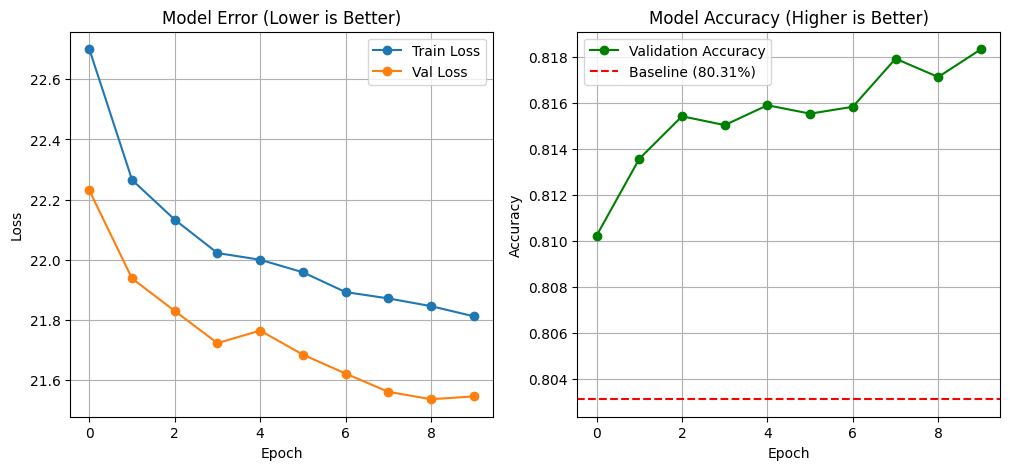

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Graph 1: Loss (The Error)
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', marker='o')
plt.plot(history['val_loss'], label='Val Loss', marker='o')
plt.title("Model Error (Lower is Better)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Graph 2: Accuracy (The Score)
plt.subplot(1, 2, 2)
plt.plot(history['val_acc'], label='Validation Accuracy', color='green', marker='o')
# Draw the baseline again
plt.axhline(0.8031, color='red', linestyle='--', label='Baseline (80.31%)')
plt.title("Model Accuracy (Higher is Better)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()